<a href="https://colab.research.google.com/github/siddharthpurswani/Amazon_Prime_TV_Shows_and_Review_Analysis/blob/main/Amazon_Prime_TV_Shows_and_Review_Analysis_Captone_Project_Siddharth_Purswani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Introduction**

With the streaming wars in full swing, platforms like **Amazon Prime Video** are racing to deliver vast, diverse content to capture audience attention. But behind every title lies a story told not just in scripts—but in **data**.




**Project name: Amazon Prime Customer Interaction Analysis**

Through exploratory data analysis and visualization, this project seeks to answer questions related to:

- Content diversity (e.g., genre distribution)
- Popularity and ratings (e.g., top-rated shows/movies)
- Temporal trends (e.g., changes over release years)
- Regional production patterns
- Key actors and directors on the platform

Let’s dive in to better understand the composition and trends of Amazon Prime’s U.S. content library.


# Loading the data

The first step is to load the datasets into pandas DataFrames. We'll be using two datasets: one containing information about the titles on Amazon Prime Video and another containing credit information for those titles.

In [212]:
import pandas as pd

sheet_url = "https://docs.google.com/spreadsheets/d/1NlH4pexTkqgeyNODF-5q8PtRP7ZOSO4ngyfPDBjKEjc/export?format=csv"
csv_url = sheet_url.replace("/edit?usp=sharing", "/export?format=csv")

credits_df = pd.read_csv(csv_url)
credits_df.head()

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


In [213]:
import pandas as pd

# Google Sheet URL - formatted for CSV export
csv_url_2 = "https://docs.google.com/spreadsheets/d/18wQtUWnL3hr6FlbndrA5LJaNnQwoziKdkmUD5-St9JM/export?format=csv"

# Attempt to read the CSV from the Google Sheet
titles_df = pd.read_csv(csv_url_2)

# Show the first few rows to understand structure
titles_df.head(10)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6
5,tm160494,Stagecoach,MOVIE,A group of people traveling on a stagecoach fi...,1939,NaN,96,"['western', 'drama']",['US'],NaN,tt0031971,7.8,48149.0,11.786,7.7
6,tm87233,It's a Wonderful Life,MOVIE,A holiday favourite for generations... George...,1946,PG,130,"['drama', 'family', 'fantasy', 'romance', 'com...",['US'],NaN,tt0038650,8.6,444243.0,26.495,8.3
7,tm19424,Detour,MOVIE,"The life of Al Roberts, a pianist in a New Yor...",1945,NaN,66,"['thriller', 'drama', 'crime']",['US'],NaN,tt0037638,7.3,17233.0,7.757,7.2
8,tm116781,My Man Godfrey,MOVIE,"Fifth Avenue socialite Irene Bullock needs a ""...",1936,NaN,95,"['comedy', 'romance', 'drama']",['US'],NaN,tt0028010,8.0,23532.0,8.633,7.6
9,tm112005,Marihuana,MOVIE,A young girl named Burma attends a beach party...,1936,NaN,57,"['crime', 'drama']",['US'],NaN,tt0026683,4.0,864.0,3.748,3.6


In [214]:
titles_df.head(5)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


# Data Wrangling

Next, we'll clean and transform the data to make it suitable for analysis. This includes handling missing values, merging the two dataframes, and cleaning the lists in some columns.

In [215]:
print(titles_df['genres'].notna().sum())

9871


In [216]:
titles_df[['seasons']] = titles_df[['seasons']].fillna(0)

In [217]:
titles_df['age_certification'] = titles_df['age_certification'].fillna('Unrated')

In [285]:
titles_df['seasons'].unique()

array([26.,  0., 18.,  9., 31.,  6., 12., 49.,  3., 11., 51., 22.,  8.,
        2.,  4.,  1.,  7., 16., 24., 35.,  5., 34., 13., 15., 42., 33.,
       10., 25., 14., 19., 21., 17., 28.])

In [219]:
merge_df = pd.merge(titles_df, credits_df, on='id')

In [220]:
merge_df.drop(['person_id','description','imdb_id'],inplace = True, axis = 1)

In [221]:
merge_df.head(5)

,id,title,type,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,name,character,role
0,ts20945,The Three Stooges,SHOW,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,8.6,1092.0,15.424,7.6,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,8.6,1092.0,15.424,7.6,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,8.6,1092.0,15.424,7.6,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,1926,Unrated,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],0.0,8.2,89766.0,8.647,8.0,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,1926,Unrated,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],0.0,8.2,89766.0,8.647,8.0,Marion Mack,Annabelle Lee,ACTOR


Group by dataframe based on id and role to avoid multiple enteries and making id as unique identifier

In [222]:
grouped_df = merge_df.groupby(['id','role']).agg({
    'title': 'first',
    'type': 'first',
    'release_year': 'first',
    'age_certification': 'first',
    'runtime': 'first',
    'genres': 'first',
    'tmdb_popularity': 'first',
    'tmdb_score': 'first',
    'imdb_score': 'first',
    'imdb_votes': 'first',
    'production_countries': 'first',
    'character': lambda x: list(x),
    'name': lambda x: list(x)
}).reset_index()

In [223]:
grouped_df.head(5)

,id,role,title,type,release_year,age_certification,runtime,genres,tmdb_popularity,tmdb_score,imdb_score,imdb_votes,production_countries,character,name
0,tm100001,ACTOR,The Lucky Texan,MOVIE,1934,Unrated,61,"['western', 'action', 'romance']",4.079,4.7,5.6,1213.0,['US'],"[Jerry Mason, Betty Benson, Harris, Jake 'Gran...","[John Wayne, Barbara Sheldon, Lloyd Whitlock, ..."
1,tm100001,DIRECTOR,The Lucky Texan,MOVIE,1934,Unrated,61,"['western', 'action', 'romance']",4.079,4.7,5.6,1213.0,['US'],[nan],[Robert N. Bradbury]
2,tm1000022,ACTOR,Boonie Bears: The Wild Life,MOVIE,2021,Unrated,99,"['scifi', 'animation']",6.135,3.8,5.4,117.0,['CN'],"[nan, nan, nan, 熊大 (配音)]","[Chris Boike, Nikki Stinson, Tan Xiao, 张伟]"
3,tm1000022,DIRECTOR,Boonie Bears: The Wild Life,MOVIE,2021,Unrated,99,"['scifi', 'animation']",6.135,3.8,5.4,117.0,['CN'],[nan],[Leon Ding]
4,tm1000169,ACTOR,Bad Cupid,MOVIE,2021,Unrated,81,"['romance', 'comedy']",3.295,4.8,4.4,181.0,[],"[Archie, Dave, Morris, Henry, Stella, Denise, ...","[John Rhys-Davies, Shane Nepveu, Briana Marin,..."


In [224]:
grouped_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16352 entries, 0 to 16351
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    16352 non-null  object 
 1   role                  16352 non-null  object 
 2   title                 16352 non-null  object 
 3   type                  16352 non-null  object 
 4   release_year          16352 non-null  int64  
 5   age_certification     16352 non-null  object 
 6   runtime               16352 non-null  int64  
 7   genres                16352 non-null  object 
 8   tmdb_popularity       16343 non-null  float64
 9   tmdb_score            14170 non-null  float64
 10  imdb_score            15121 non-null  float64
 11  imdb_votes            15115 non-null  float64
 12  production_countries  16352 non-null  object 
 13  character             16352 non-null  object 
 14  name                  16352 non-null  object 
dtypes: float64(4), int6

In [225]:
grouped_df['character'] = grouped_df['character'].apply(lambda x: [name for name in x if pd.notna(name) and name!= ''])

In [226]:
grouped_df

,id,role,title,type,release_year,age_certification,runtime,genres,tmdb_popularity,tmdb_score,imdb_score,imdb_votes,production_countries,character,name
0,tm100001,ACTOR,The Lucky Texan,MOVIE,1934,Unrated,61,"['western', 'action', 'romance']",4.079,4.7,5.6,1213.0,['US'],"[Jerry Mason, Betty Benson, Harris, Jake 'Gran...","[John Wayne, Barbara Sheldon, Lloyd Whitlock, ..."
1,tm100001,DIRECTOR,The Lucky Texan,MOVIE,1934,Unrated,61,"['western', 'action', 'romance']",4.079,4.7,5.6,1213.0,['US'],[],[Robert N. Bradbury]
2,tm1000022,ACTOR,Boonie Bears: The Wild Life,MOVIE,2021,Unrated,99,"['scifi', 'animation']",6.135,3.8,5.4,117.0,['CN'],[熊大 (配音)],"[Chris Boike, Nikki Stinson, Tan Xiao, 张伟]"
3,tm1000022,DIRECTOR,Boonie Bears: The Wild Life,MOVIE,2021,Unrated,99,"['scifi', 'animation']",6.135,3.8,5.4,117.0,['CN'],[],[Leon Ding]
4,tm1000169,ACTOR,Bad Cupid,MOVIE,2021,Unrated,81,"['romance', 'comedy']",3.295,4.8,4.4,181.0,[],"[Archie, Dave, Morris, Henry, Stella, Denise, ...","[John Rhys-Davies, Shane Nepveu, Briana Marin,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16347,ts97421,ACTOR,Chronofilm,SHOW,2020,Unrated,20,['scifi'],0.840,NaN,5.7,16.0,['US'],[],"[Joseph Hypes, Madison Mitchell, Colton Dennis..."
16348,ts97421,DIRECTOR,Chronofilm,SHOW,2020,Unrated,20,['scifi'],0.840,NaN,5.7,16.0,['US'],[],[Robert Hypes]
16349,ts97576,ACTOR,Volatile Earth,SHOW,2017,Unrated,47,['documentation'],0.630,8.0,7.2,24.0,['GB'],[Narrator (Voice)],[Mark Bazeley]
16350,ts9770,ACTOR,The Adventures of Tintin,SHOW,1991,TV-Y7,23,"['action', 'animation', 'family', 'comedy', 'c...",25.766,8.0,8.2,17859.0,"['US', 'BE', 'CA', 'FR']","[Tintin (voice), Capitaine Haddock (voice), Pr...","[Thierry Wermuth, Christian Pelissier, Henri L..."


In [227]:
print(grouped_df.isna().sum())

id                         0
role                       0
title                      0
type                       0
release_year               0
age_certification          0
runtime                    0
genres                     0
tmdb_popularity            9
tmdb_score              2182
imdb_score              1231
imdb_votes              1237
production_countries       0
character                  0
name                       0
dtype: int64


In [228]:
grouped_df.dropna(subset=['tmdb_popularity'], inplace=True)

In [229]:
grouped_df

,id,role,title,type,release_year,age_certification,runtime,genres,tmdb_popularity,tmdb_score,imdb_score,imdb_votes,production_countries,character,name
0,tm100001,ACTOR,The Lucky Texan,MOVIE,1934,Unrated,61,"['western', 'action', 'romance']",4.079,4.7,5.6,1213.0,['US'],"[Jerry Mason, Betty Benson, Harris, Jake 'Gran...","[John Wayne, Barbara Sheldon, Lloyd Whitlock, ..."
1,tm100001,DIRECTOR,The Lucky Texan,MOVIE,1934,Unrated,61,"['western', 'action', 'romance']",4.079,4.7,5.6,1213.0,['US'],[],[Robert N. Bradbury]
2,tm1000022,ACTOR,Boonie Bears: The Wild Life,MOVIE,2021,Unrated,99,"['scifi', 'animation']",6.135,3.8,5.4,117.0,['CN'],[熊大 (配音)],"[Chris Boike, Nikki Stinson, Tan Xiao, 张伟]"
3,tm1000022,DIRECTOR,Boonie Bears: The Wild Life,MOVIE,2021,Unrated,99,"['scifi', 'animation']",6.135,3.8,5.4,117.0,['CN'],[],[Leon Ding]
4,tm1000169,ACTOR,Bad Cupid,MOVIE,2021,Unrated,81,"['romance', 'comedy']",3.295,4.8,4.4,181.0,[],"[Archie, Dave, Morris, Henry, Stella, Denise, ...","[John Rhys-Davies, Shane Nepveu, Briana Marin,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16347,ts97421,ACTOR,Chronofilm,SHOW,2020,Unrated,20,['scifi'],0.840,NaN,5.7,16.0,['US'],[],"[Joseph Hypes, Madison Mitchell, Colton Dennis..."
16348,ts97421,DIRECTOR,Chronofilm,SHOW,2020,Unrated,20,['scifi'],0.840,NaN,5.7,16.0,['US'],[],[Robert Hypes]
16349,ts97576,ACTOR,Volatile Earth,SHOW,2017,Unrated,47,['documentation'],0.630,8.0,7.2,24.0,['GB'],[Narrator (Voice)],[Mark Bazeley]
16350,ts9770,ACTOR,The Adventures of Tintin,SHOW,1991,TV-Y7,23,"['action', 'animation', 'family', 'comedy', 'c...",25.766,8.0,8.2,17859.0,"['US', 'BE', 'CA', 'FR']","[Tintin (voice), Capitaine Haddock (voice), Pr...","[Thierry Wermuth, Christian Pelissier, Henri L..."


In [230]:
grouped_df['imdb_votes'].fillna(0, inplace=True)

/tmp/ipython-input-2195158824.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  grouped_df['imdb_votes'].fillna(0, inplace=True)


In [231]:
grouped_df['imdb_votes'].fillna(0, inplace=True)

/tmp/ipython-input-2195158824.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  grouped_df['imdb_votes'].fillna(0, inplace=True)


In [232]:
grouped_df['tmdb_popularity'].fillna(0, inplace=True)

/tmp/ipython-input-3022534652.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  grouped_df['tmdb_popularity'].fillna(0, inplace=True)


In [233]:
grouped_df.head(5)

,id,role,title,type,release_year,age_certification,runtime,genres,tmdb_popularity,tmdb_score,imdb_score,imdb_votes,production_countries,character,name
0,tm100001,ACTOR,The Lucky Texan,MOVIE,1934,Unrated,61,"['western', 'action', 'romance']",4.079,4.7,5.6,1213.0,['US'],"[Jerry Mason, Betty Benson, Harris, Jake 'Gran...","[John Wayne, Barbara Sheldon, Lloyd Whitlock, ..."
1,tm100001,DIRECTOR,The Lucky Texan,MOVIE,1934,Unrated,61,"['western', 'action', 'romance']",4.079,4.7,5.6,1213.0,['US'],[],[Robert N. Bradbury]
2,tm1000022,ACTOR,Boonie Bears: The Wild Life,MOVIE,2021,Unrated,99,"['scifi', 'animation']",6.135,3.8,5.4,117.0,['CN'],[熊大 (配音)],"[Chris Boike, Nikki Stinson, Tan Xiao, 张伟]"
3,tm1000022,DIRECTOR,Boonie Bears: The Wild Life,MOVIE,2021,Unrated,99,"['scifi', 'animation']",6.135,3.8,5.4,117.0,['CN'],[],[Leon Ding]
4,tm1000169,ACTOR,Bad Cupid,MOVIE,2021,Unrated,81,"['romance', 'comedy']",3.295,4.8,4.4,181.0,[],"[Archie, Dave, Morris, Henry, Stella, Denise, ...","[John Rhys-Davies, Shane Nepveu, Briana Marin,..."


Created seperate dataframe for actor and director for the ease of further analysis

In [234]:
actor_grouped_df = grouped_df[grouped_df['role'] == 'ACTOR']

In [235]:
grouped_df.fillna({'imdb_score': 0, 'tmdb_score': 0}, inplace=True)

In [236]:
director_grouped_df = grouped_df[grouped_df['role'] == 'DIRECTOR']

In [237]:
director_grouped_df.head(5)

,id,role,title,type,release_year,age_certification,runtime,genres,tmdb_popularity,tmdb_score,imdb_score,imdb_votes,production_countries,character,name
1,tm100001,DIRECTOR,The Lucky Texan,MOVIE,1934,Unrated,61,"['western', 'action', 'romance']",4.079,4.7,5.6,1213.0,['US'],[],[Robert N. Bradbury]
3,tm1000022,DIRECTOR,Boonie Bears: The Wild Life,MOVIE,2021,Unrated,99,"['scifi', 'animation']",6.135,3.8,5.4,117.0,['CN'],[],[Leon Ding]
5,tm1000169,DIRECTOR,Bad Cupid,MOVIE,2021,Unrated,81,"['romance', 'comedy']",3.295,4.8,4.4,181.0,[],[],"[Diane Cossa, Neal Howard]"
7,tm1000203,DIRECTOR,Digging to Death,MOVIE,2021,Unrated,96,"['horror', 'thriller']",3.543,5.8,4.5,464.0,['US'],[],[Michael P. Blevins]
9,tm1000290,DIRECTOR,Secrets in the Water,MOVIE,2020,Unrated,77,['thriller'],5.825,7.4,0.0,0.0,['US'],[],[Michael Feifer]


In [238]:
all_names = [name for sublist in actor_grouped_df['name'] for name in sublist]

list_of_actor = list(all_names)


In [239]:
all_names_1 = [name for sublist in director_grouped_df['name'] for name in sublist]

list_of_director = list(all_names_1)

In [240]:
list_of_actor[-1]

'Martin Short'

# Exploratory Data Analysis (EDA)


Now that the data is clean, we'll perform some exploratory data analysis to understand the distribution of key features and identify interesting patterns. This includes looking at the unique values in categorical columns, analyzing the distribution of genres and age certifications, and examining the trend of average popularity and votes over time.

In [241]:
grouped_df[grouped_df['age_certification'] == 'R']

,id,role,title,type,release_year,age_certification,runtime,genres,tmdb_popularity,tmdb_score,imdb_score,imdb_votes,production_countries,character,name
12,tm1000406,ACTOR,Dark Corners,MOVIE,2021,R,90,['thriller'],2.999,8.0,4.0,81.0,"['GB', 'NO']","[Strachan, Page, Veronique, Karim, Fleet, Tom,...","[Sam Hazeldine, Julie Dray, Dany Verissimo-Pet..."
13,tm1000406,DIRECTOR,Dark Corners,MOVIE,2021,R,90,['thriller'],2.999,8.0,4.0,81.0,"['GB', 'NO']",[],[Richard Parry]
26,tm100158,ACTOR,Investigation of a Citizen Above Suspicion,MOVIE,1970,R,111,"['drama', 'thriller', 'european', 'crime']",8.996,8.2,8.0,11130.0,['IT'],"[Dottore, Augusta Terzi, Police Prefect, Bigli...","[Gian Maria Volonté, Florinda Bolkan, Gianni S..."
27,tm100158,DIRECTOR,Investigation of a Citizen Above Suspicion,MOVIE,1970,R,111,"['drama', 'thriller', 'european', 'crime']",8.996,8.2,8.0,11130.0,['IT'],[],[Elio Petri]
28,tm1001637,ACTOR,Bunty Aur Babli 2,MOVIE,2021,R,138,"['crime', 'drama', 'romance', 'comedy']",3.277,4.5,4.0,3700.0,['IN'],"[Rakesh Trivedi aka ""Bunty"", Vimmy Trivedi aka...","[Saif Ali Khan, Rani Mukerji, Siddhant Chaturv..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15025,tm99598,DIRECTOR,Carter's Army,MOVIE,1970,R,73,"['war', 'drama']",1.801,4.7,5.1,538.0,['US'],[],[George McCowan]
15030,tm996488,ACTOR,Archive,MOVIE,2020,R,109,"['fantasy', 'thriller', 'scifi', 'drama']",12.345,6.2,6.3,18923.0,"['HU', 'US', 'GB']","[George Almore, Jules Almore / J3 / J2 (voice)...","[Theo James, Stacy Martin, Rhona Mitra, Peter ..."
15031,tm996488,DIRECTOR,Archive,MOVIE,2020,R,109,"['fantasy', 'thriller', 'scifi', 'drama']",12.345,6.2,6.3,18923.0,"['HU', 'US', 'GB']",[],[Gavin Rothery]
15074,tm99884,ACTOR,Black Fist,MOVIE,1977,R,93,"['drama', 'crime', 'action']",2.212,5.0,5.0,446.0,['US'],"[Leroy Fisk, Florence, Fletch & Boom Boom, Log...","[Richard Lawson, Annazette Chase, Philip Micha..."


In [242]:
grouped_df.isna().sum()

,0
id,0
role,0
title,0
type,0
release_year,0
age_certification,0
runtime,0
genres,0
tmdb_popularity,0
tmdb_score,0


In [243]:
grouped_df.describe()

,release_year,runtime,tmdb_popularity,tmdb_score,imdb_score,imdb_votes
count,16343.000000,16343.000000,16343.000000,16343.000000,16343.000000,1.634300e+04
mean,1998.950254,90.528116,6.786988,5.115988,5.429848,8.481805e+03
std,27.199653,29.954423,29.922359,2.423225,1.986551,4.608612e+04
min,1912.000000,1.000000,0.000011,0.000000,0.000000,0.000000e+00
25%,1989.000000,75.000000,1.395000,4.400000,4.800000,1.100000e+02
50%,2013.000000,90.000000,2.693000,5.800000,5.800000,4.650000e+02
75%,2018.000000,104.000000,5.688000,6.700000,6.700000,2.237000e+03
max,2022.000000,540.000000,1437.906000,10.000000,9.900000,1.133692e+06


In [244]:
categorical_fields = ['type', 'age_certification', 'genres', 'role']


In [245]:
unique_counts = {}

for field in categorical_fields:
    if grouped_df[field].apply(lambda x: isinstance(x, list)).any():
        all_items = grouped_df[field].dropna().explode()
        unique_counts[field] = all_items.nunique()
    else:
        unique_counts[field] = grouped_df[field].nunique()

for field, count in unique_counts.items():
    print(f"Unique values in '{field}': {count}")

Unique values in 'type': 2
Unique values in 'age_certification': 12
Unique values in 'genres': 1964
Unique values in 'role': 2


Struggle to convert genres to pure list without duplicate values(Never going to forget)

In [248]:
grouped_df['genres'] = grouped_df['genres'].apply(lambda x: x[1:-1]).str.split(',')

In [249]:
def remove_quotes(value):
    for word in value:
        if "'" in word:
            word = word.replace("'", "")
    return value

In [250]:
def remove_space(value):
    for word in value:
        if " " in word:
            word = word.replace(" ", "")
    return value

In [251]:
def clean_strings(arr):
    return [s.strip(" '\"") for s in arr if s != '']

In [253]:
grouped_df['genres'] = grouped_df['genres'].apply(remove_quotes)

In [254]:
grouped_df['genres'] = grouped_df['genres'].apply(remove_space)

In [255]:
grouped_df['genres'] = grouped_df['genres'].apply(clean_strings)

In [256]:
grouped_df['genres'].apply(type)

,genres
0,<class 'list'>
1,<class 'list'>
2,<class 'list'>
3,<class 'list'>
4,<class 'list'>
...,...
16347,<class 'list'>
16348,<class 'list'>
16349,<class 'list'>
16350,<class 'list'>


In [275]:
genres_count = grouped_df['genres'].explode().value_counts().head(10)

# Data Visualization!


Great! Now that the Exploratory Data Analysis (EDA) is complete, we’ll move into the data visualization phase to bring our findings to life.

This bar chart shows the top 10 most frequent genres in the Amazon Prime Video library. The genres are on the y-axis and the count of titles in each genre is on the x-axis. As you can see, 'drama' and 'comedy' are the most common genres.



In [276]:
import matplotlib.pyplot as plt

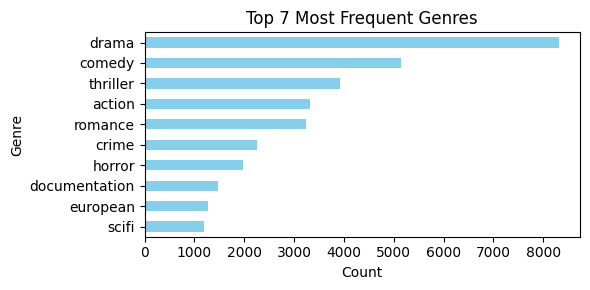

In [277]:
plt.figure(figsize=(6, 3))
genres_count.sort_values().plot(kind='barh', color='skyblue')
plt.title('Top 7 Most Frequent Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

Age Certification: Among rated content, 'R', 'PG-13', and 'PG' are the most common age certifications. This indicates a substantial amount of content is geared towards mature audiences, but there's also a good representation of content suitable for younger viewers.

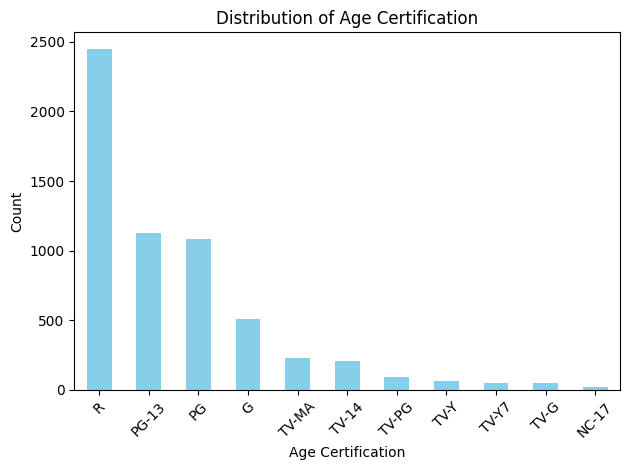

In [259]:
age_graph = grouped_df['age_certification'].value_counts()
new_age_graph = age_graph.drop('Unrated')
new_age_graph.plot(kind='bar', color='skyblue')
plt.title('Distribution of Age Certification')
plt.xlabel('Age Certification')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This chart illustrates the trend in TMDB (The Movie Database) popularity over time. It shows that from the early 1990s up until the late 2010s, overall popularity remained relatively low and stable. However, starting around 2020, there's a noticeable surge in popularity—indicating that movies and shows have been receiving significantly more attention and viewership in recent years. This spike aligns with changing consumption habits, increased streaming access, and global trends in digital entertainment.

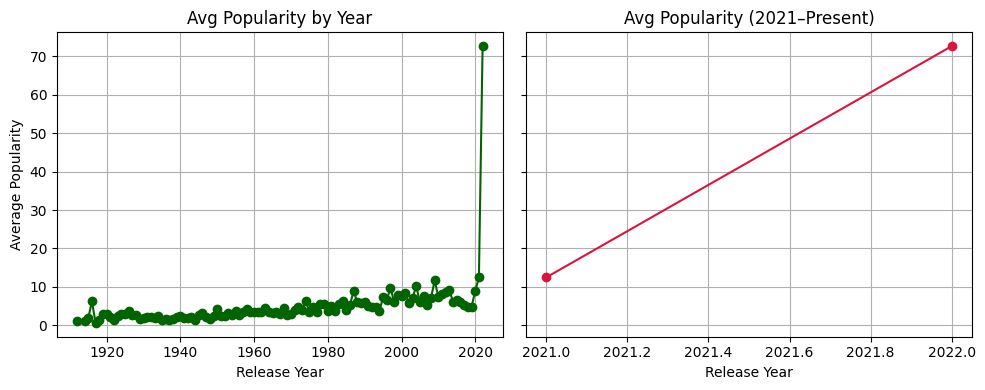

In [260]:
import matplotlib.pyplot as plt

# Step 1: Clean the data
clean_df = grouped_df[['release_year', 'tmdb_popularity']].dropna()

# Step 2: Group full range
popularity_all = clean_df.groupby('release_year')['tmdb_popularity'].mean().sort_index()

# Step 3: Filter for recent years
recent_df = clean_df[clean_df['release_year'] > 2020]
popularity_recent = recent_df.groupby('release_year')['tmdb_popularity'].mean().sort_index()

# Step 4: Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Left plot: All years
axes[0].plot(popularity_all.index, popularity_all.values, marker='o', color='darkgreen')
axes[0].set_title('Avg Popularity by Year')
axes[0].set_xlabel('Release Year')
axes[0].set_ylabel('Average Popularity')
axes[0].grid(True)

# Right plot: 2021–Present
axes[1].plot(popularity_recent.index, popularity_recent.values, marker='o', color='crimson')
axes[1].set_title('Avg Popularity (2021–Present)')
axes[1].set_xlabel('Release Year')
axes[1].grid(True)

plt.tight_layout()
plt.show()


This chart shows that IMDb votes were highly popular between 1980 and 2000, reflecting strong audience engagement during that era. However, in recent years, the voting trend has plateaued, indicating a shift in how viewers interact with content. The hype was concentrated in the golden age of cinema, when blockbuster releases and cult classics drove massive public interest and participation.

IMDb aggregates votes from a wide range of users and includes films dating back decades, it's natural that movies from the 1980s to early 2000s show higher vote counts. During that period, many iconic films gained cult followings and long-term popularity, leading to sustained voting activity over time. The hype was rooted in the legacy of classic cinema, and those historical records continue to reflect strong audience engagement even today.

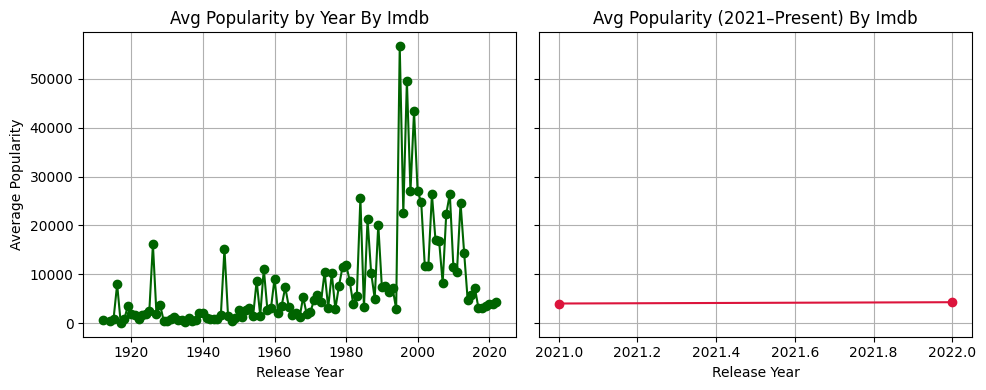

In [261]:
import matplotlib.pyplot as plt

# Step 1: Clean the data
clean_df = grouped_df[['release_year', 'imdb_votes']].dropna()

# Step 2: Group full range
popularity_all = clean_df.groupby('release_year')['imdb_votes'].mean().sort_index()

# Step 3: Filter for recent years
recent_df = clean_df[clean_df['release_year'] > 2020]
popularity_recent = recent_df.groupby('release_year')['imdb_votes'].mean().sort_index()

# Step 4: Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Left plot: All years
axes[0].plot(popularity_all.index, popularity_all.values, marker='o', color='darkgreen')
axes[0].set_title('Avg Popularity by Year By Imdb')
axes[0].set_xlabel('Release Year')
axes[0].set_ylabel('Average Popularity')
axes[0].grid(True)

# Right plot: 2021–Present
axes[1].plot(popularity_recent.index, popularity_recent.values, marker='o', color='crimson')
axes[1].set_title('Avg Popularity (2021–Present) By Imdb')
axes[1].set_xlabel('Release Year')
axes[1].grid(True)

plt.tight_layout()
plt.show()


This chart illustrates the trend in movie production over the years. It reveals a steady output in earlier decades, followed by a noticeable rise starting around 2015. This surge likely reflects the growth of streaming platforms, increased global investment in content creation, and easier access to filmmaking technology—making it more feasible for studios and independent creators to produce and release films at a higher volume.

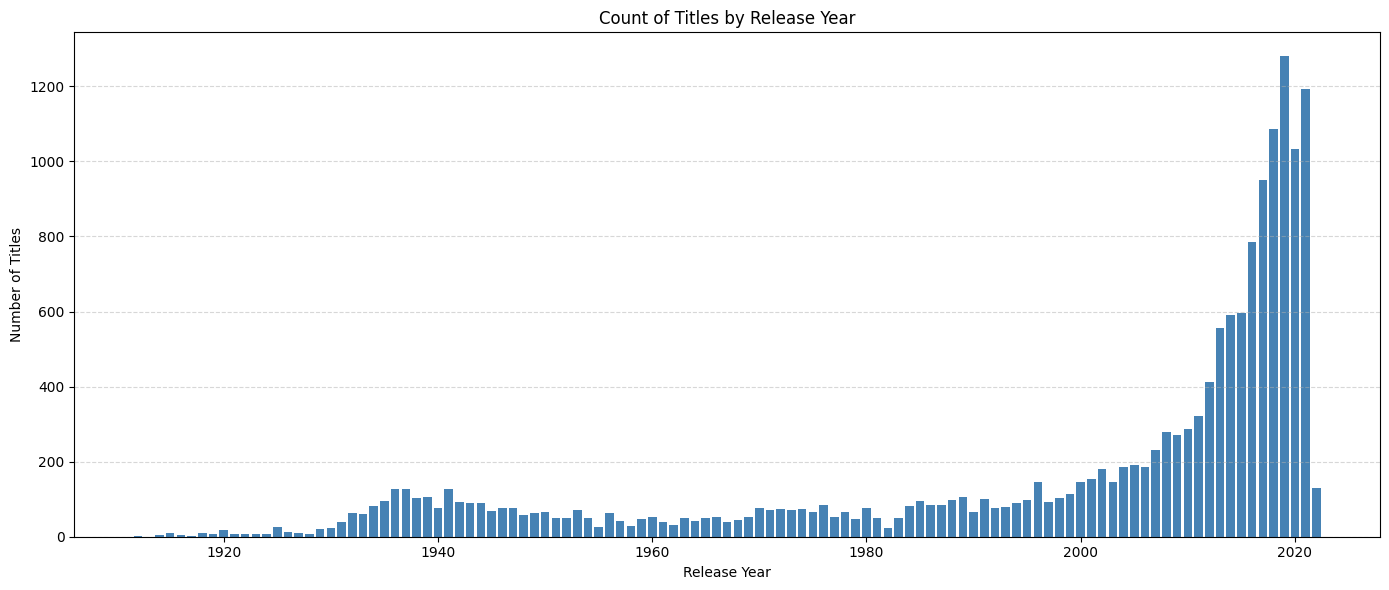

In [262]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Group and count titles by release year
year_counts = grouped_df['release_year'].value_counts().sort_index()

# Step 2: Plot bar chart
plt.figure(figsize=(14, 6))
plt.bar(year_counts.index, year_counts.values, color='steelblue')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.title('Count of Titles by Release Year')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

This chart highlights a growing trend: TV shows have been attracting more attention than movies in recent years, both on IMDb and TMDB. The spike in popularity reflects changing viewer habits, with audiences increasingly drawn to serialized content and binge-worthy formats.

However, the comparison rate appears lower on IMDb because it incorporates a broader historical dataset. Many older movies have accumulated votes and ratings over decades, which can overshadow recent trends. TMDB, being more reflective of current viewing patterns, shows a sharper rise in TV show engagement.

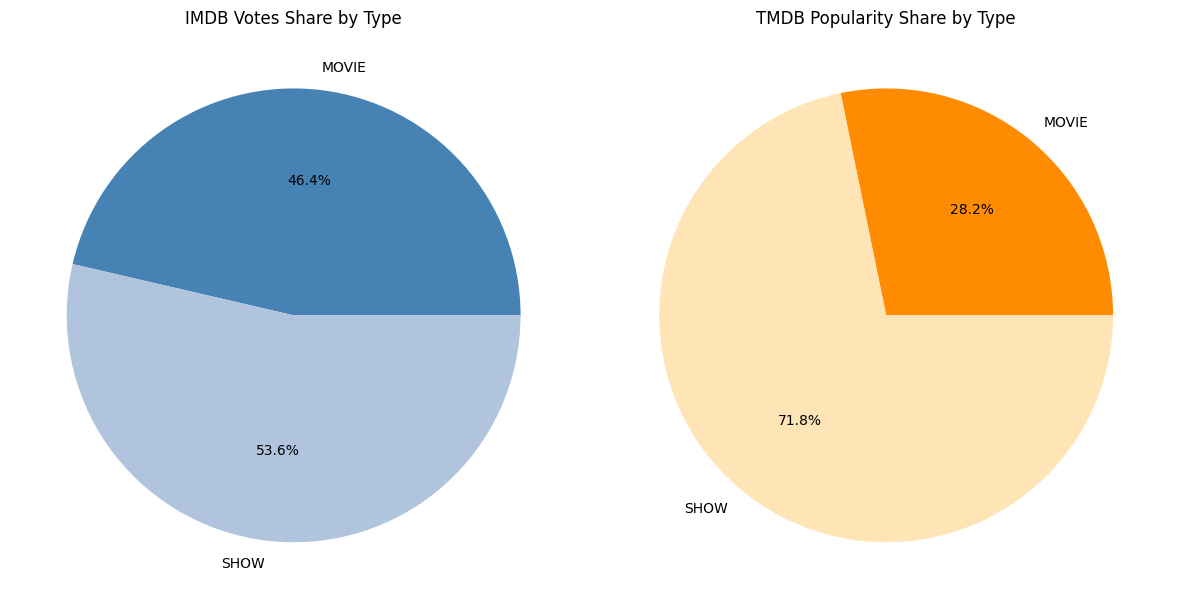

In [263]:
import matplotlib.pyplot as plt

# Step 1: Clean and group data
clean_df = grouped_df[['type', 'imdb_votes', 'tmdb_popularity']].dropna()
grouped_stats = clean_df.groupby('type')[['imdb_votes', 'tmdb_popularity']].mean()

# Step 2: Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# IMDB Votes Pie Chart
axes[0].pie(grouped_stats['imdb_votes'], labels=grouped_stats.index, autopct='%1.1f%%', colors=['steelblue', 'lightsteelblue'])
axes[0].set_title('IMDB Votes Share by Type')

# TMDB Popularity Pie Chart
axes[1].pie(grouped_stats['tmdb_popularity'], labels=grouped_stats.index, autopct='%1.1f%%', colors=['darkorange', 'moccasin'])
axes[1].set_title('TMDB Popularity Share by Type')

# Final layout
plt.tight_layout()
plt.show()


# Top Movies and TV shows as per ratings and votes of imdb and tmdb

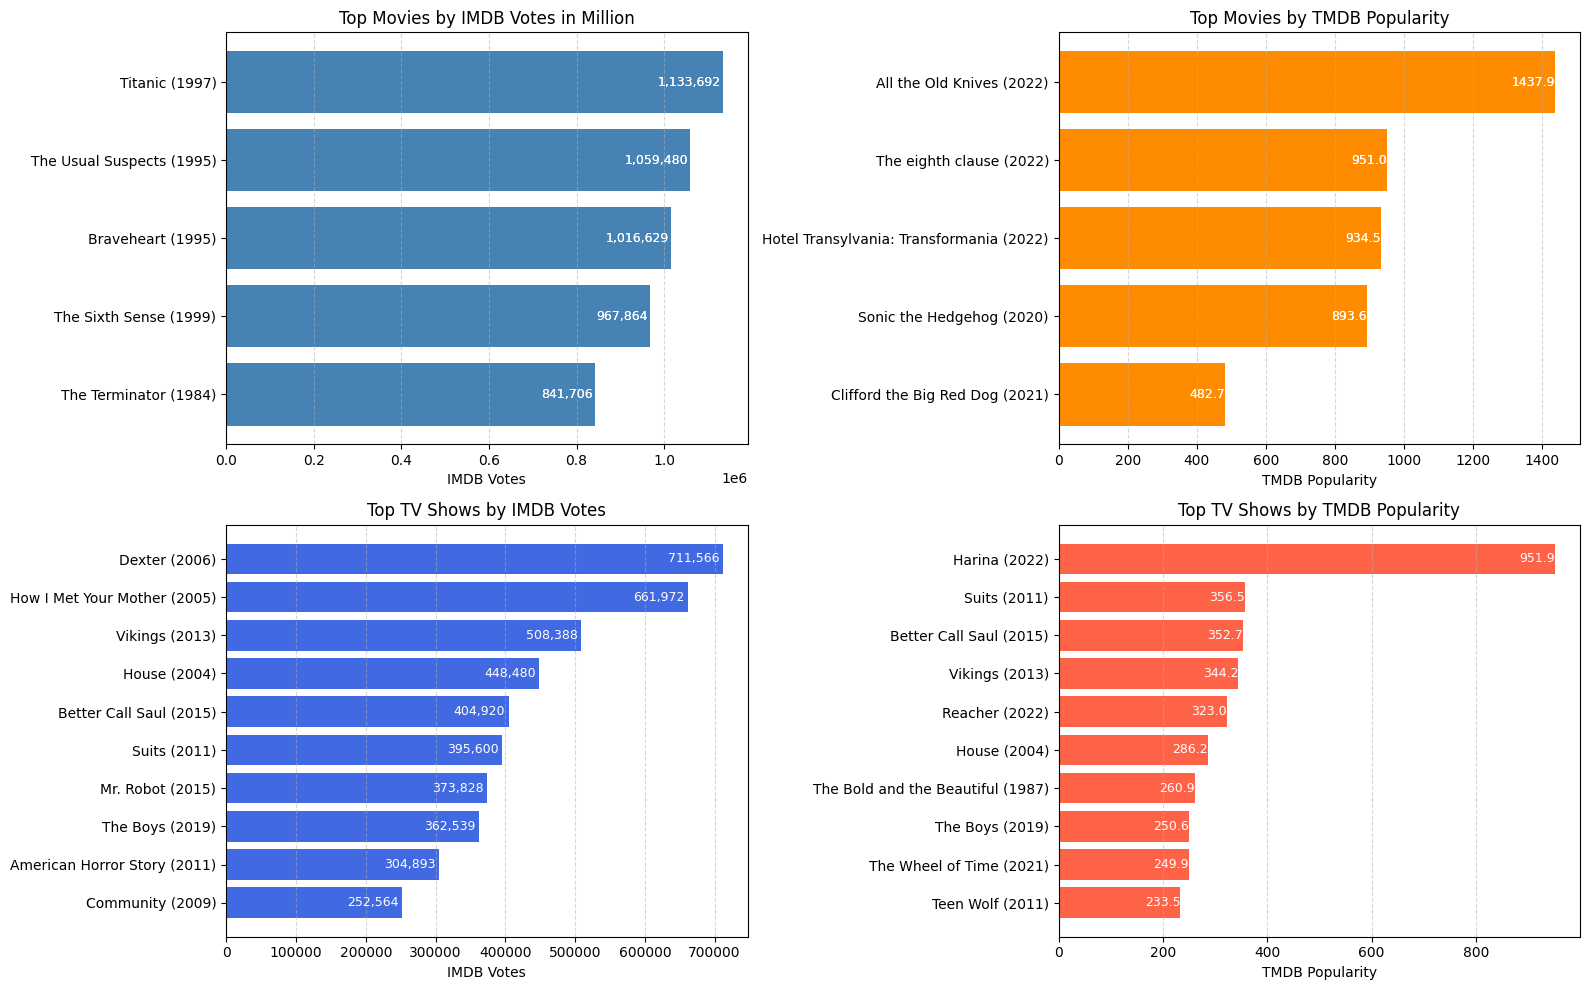

In [264]:
import matplotlib.pyplot as plt

# Step 1: Clean and prepare data
clean_df = grouped_df[['title', 'type', 'release_year', 'imdb_votes', 'tmdb_popularity']].dropna()

# Step 2: Create label with title and release year
clean_df['label'] = clean_df['title'] + ' (' + clean_df['release_year'].astype(str) + ')'

# Step 3: Separate movies and TV shows
movies_df = clean_df[clean_df['type'] == 'MOVIE']
tv_df = clean_df[clean_df['type'] == 'SHOW']

# Step 4: Select top 10 by IMDB votes and TMDB popularity
top_imdb_movies = movies_df.sort_values(by='imdb_votes', ascending=False).head(10)
top_tmdb_movies = movies_df.sort_values(by='tmdb_popularity', ascending=False).head(10)
top_imdb_tv = tv_df.sort_values(by='imdb_votes', ascending=False).head(10)
top_tmdb_tv = tv_df.sort_values(by='tmdb_popularity', ascending=False).head(10)

# Step 5: Create subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Movies: IMDB Votes
bars = axes[0, 0].barh(top_imdb_movies['label'], top_imdb_movies['imdb_votes'], color='steelblue')
axes[0, 0].set_title('Top Movies by IMDB Votes in Million')
axes[0, 0].set_xlabel('IMDB Votes')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', linestyle='--', alpha=0.5)
for bar in bars:
    width = bar.get_width()
    axes[0, 0].text(width - 5000, bar.get_y() + bar.get_height() / 2,
                   f'{int(width):,}', ha='right', va='center', color='white', fontsize=9)

# Movies: TMDB Popularity
bars = axes[0, 1].barh(top_tmdb_movies['label'], top_tmdb_movies['tmdb_popularity'], color='darkorange')
axes[0, 1].set_title('Top Movies by TMDB Popularity')
axes[0, 1].set_xlabel('TMDB Popularity')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', linestyle='--', alpha=0.5)
for bar in bars:
    width = bar.get_width()
    axes[0, 1].text(width - 0.2, bar.get_y() + bar.get_height() / 2,
                   f'{width:.1f}', ha='right', va='center', color='white', fontsize=9)

# TV Shows: IMDB Votes
bars = axes[1, 0].barh(top_imdb_tv['label'], top_imdb_tv['imdb_votes'], color='royalblue')
axes[1, 0].set_title('Top TV Shows by IMDB Votes')
axes[1, 0].set_xlabel('IMDB Votes')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', linestyle='--', alpha=0.5)
for bar in bars:
    width = bar.get_width()
    axes[1, 0].text(width - 5000, bar.get_y() + bar.get_height() / 2,
                   f'{int(width):,}', ha='right', va='center', color='white', fontsize=9)

# TV Shows: TMDB Popularity
bars = axes[1, 1].barh(top_tmdb_tv['label'], top_tmdb_tv['tmdb_popularity'], color='tomato')
axes[1, 1].set_title('Top TV Shows by TMDB Popularity')
axes[1, 1].set_xlabel('TMDB Popularity')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', linestyle='--', alpha=0.5)
for bar in bars:
    width = bar.get_width()
    axes[1, 1].text(width - 0.2, bar.get_y() + bar.get_height() / 2,
                   f'{width:.1f}', ha='right', va='center', color='white', fontsize=9)

# Final layout
plt.tight_layout()
plt.show()


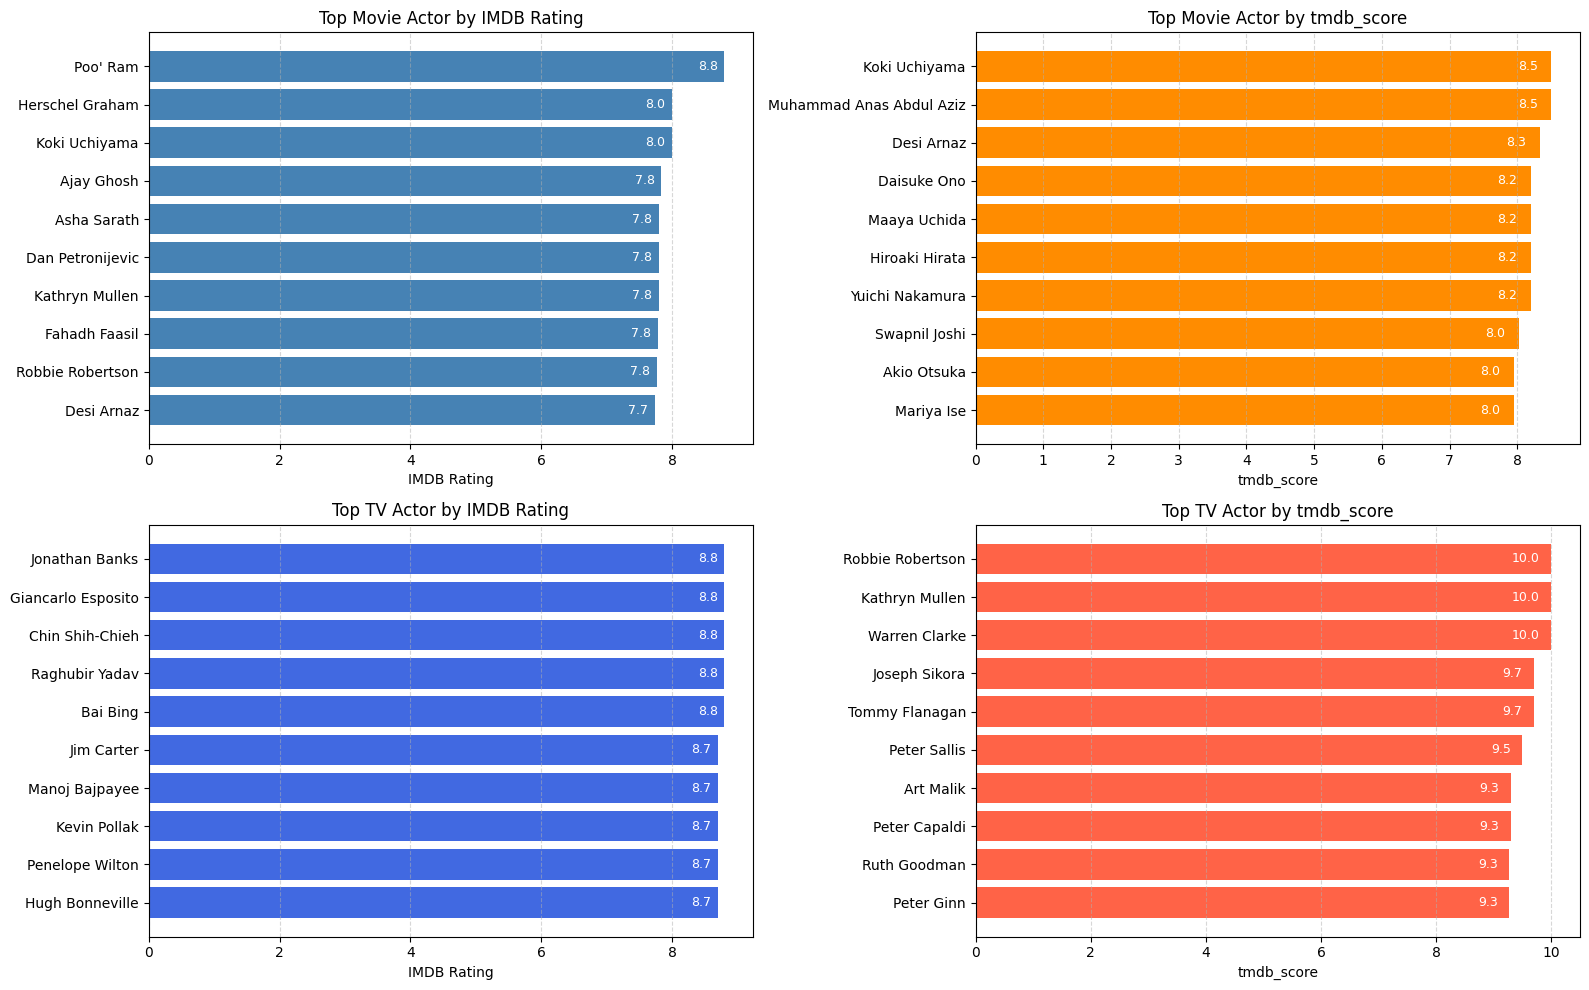

In [265]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

clean_df = actor_grouped_df[['name', 'type', 'imdb_score', 'tmdb_score']].dropna()
clean_df = clean_df.explode('name')

# Step 2: Count character appearances
char_counts = clean_df['name'].value_counts()

# Step 3: Filter characters with at least 3 appearances
valid_chars = char_counts[char_counts >= 4].index
filtered_df = clean_df[clean_df['name'].isin(valid_chars)]

# Step 3: Group by character and type
char_stats = filtered_df.groupby(['name', 'type'])[['imdb_score', 'tmdb_score']].mean().reset_index()
# Step 4: Separate movies and TV shows
movie_chars = char_stats[char_stats['type'] == 'MOVIE']
tv_chars = char_stats[char_stats['type'] == 'SHOW']

# Step 5: Select top 10 characters by each metric
top_imdb_movie_chars = movie_chars.sort_values(by='imdb_score', ascending=False).head(10)
top_tmdb_movie_chars = movie_chars.sort_values(by='tmdb_score', ascending=False).head(10)
top_imdb_tv_chars = tv_chars.sort_values(by='imdb_score', ascending=False).head(10)
top_tmdb_tv_chars = tv_chars.sort_values(by='tmdb_score', ascending=False).head(10)

# Step 6: Create subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Movies: IMDB Rating
bars = axes[0, 0].barh(top_imdb_movie_chars['name'], top_imdb_movie_chars['imdb_score'], color='steelblue')
axes[0, 0].set_title('Top Movie Actor by IMDB Rating')
axes[0, 0].set_xlabel('IMDB Rating')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', linestyle='--', alpha=0.5)
for bar in bars:
    width = bar.get_width()
    axes[0, 0].text(width - 0.1, bar.get_y() + bar.get_height()/2, f'{width:.1f}', ha='right', va='center', color='white', fontsize=9)

# Movies: TMDB Popularity
bars = axes[0, 1].barh(top_tmdb_movie_chars['name'], top_tmdb_movie_chars['tmdb_score'], color='darkorange')
axes[0, 1].set_title('Top Movie Actor by tmdb_score')
axes[0, 1].set_xlabel('tmdb_score')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', linestyle='--', alpha=0.5)
for bar in bars:
    width = bar.get_width()
    axes[0, 1].text(width - 0.2, bar.get_y() + bar.get_height()/2, f'{width:.1f}', ha='right', va='center', color='white', fontsize=9)

# TV Shows: IMDB Rating
bars = axes[1, 0].barh(top_imdb_tv_chars['name'], top_imdb_tv_chars['imdb_score'], color='royalblue')
axes[1, 0].set_title('Top TV Actor by IMDB Rating')
axes[1, 0].set_xlabel('IMDB Rating')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', linestyle='--', alpha=0.5)
for bar in bars:
    width = bar.get_width()
    axes[1, 0].text(width - 0.1, bar.get_y() + bar.get_height()/2, f'{width:.1f}', ha='right', va='center', color='white', fontsize=9)

# TV Shows: TMDB Popularity
bars = axes[1, 1].barh(top_tmdb_tv_chars['name'], top_tmdb_tv_chars['tmdb_score'], color='tomato')
axes[1, 1].set_title('Top TV Actor by tmdb_score')
axes[1, 1].set_xlabel('tmdb_score')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', linestyle='--', alpha=0.5)
for bar in bars:
    width = bar.get_width()
    axes[1, 1].text(width - 0.2, bar.get_y() + bar.get_height()/2, f'{width:.1f}', ha='right', va='center', color='white', fontsize=9)

# Final layout
plt.tight_layout()
plt.show()


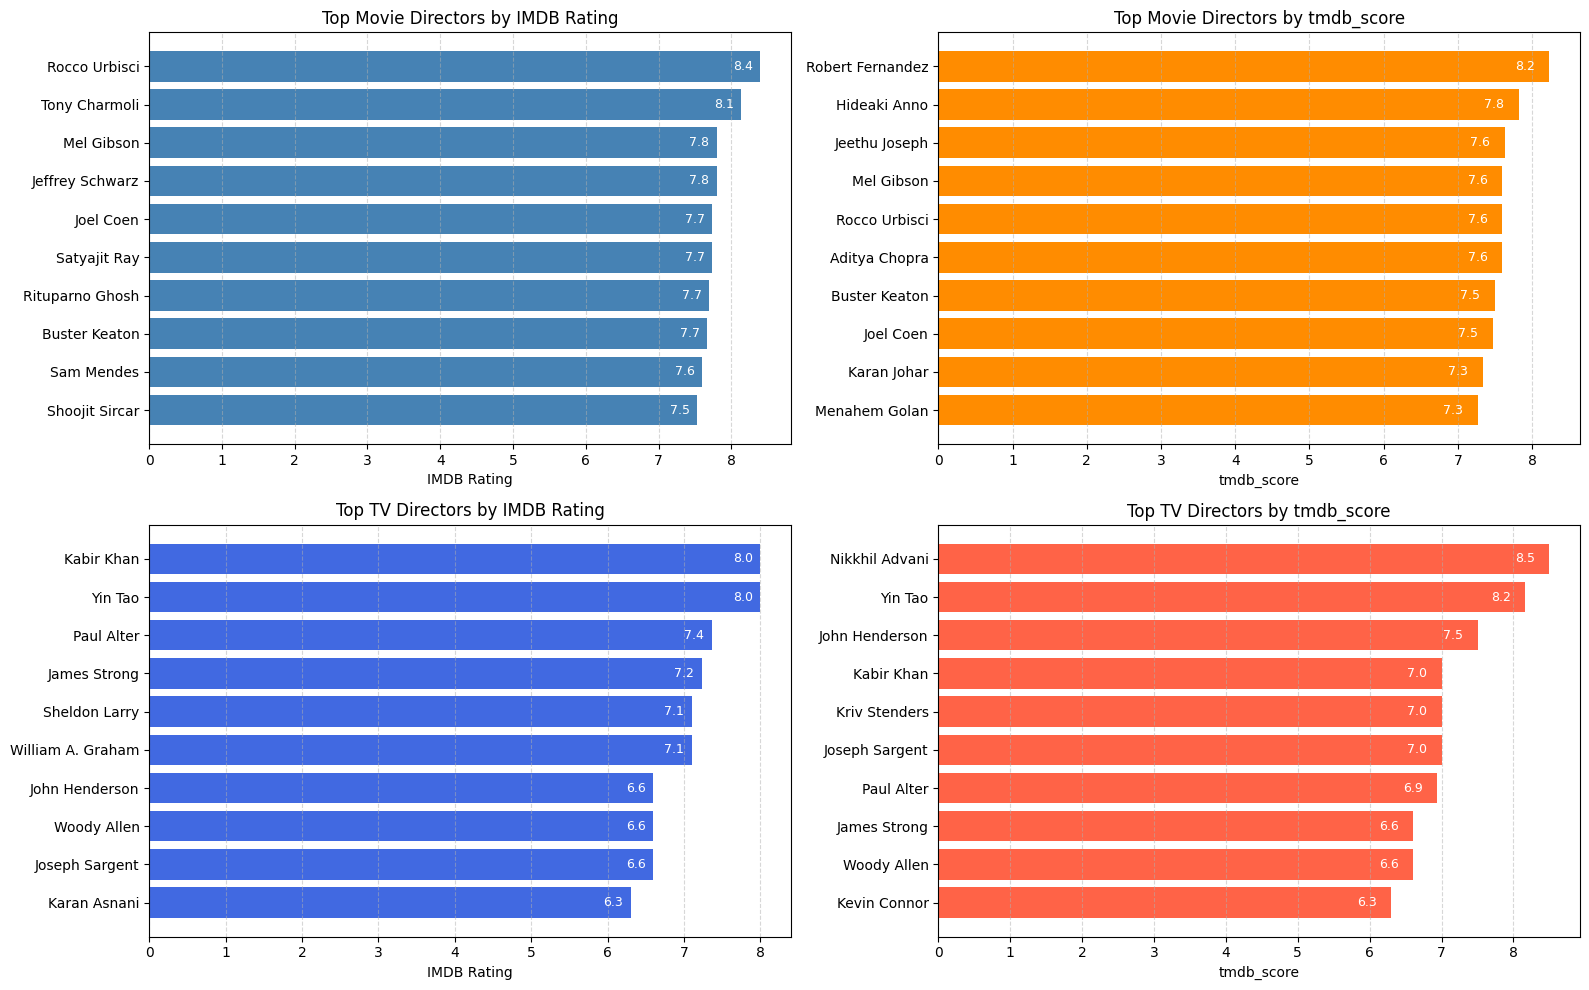

In [268]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

clean_df = director_grouped_df[['name', 'type', 'imdb_score', 'tmdb_score']].dropna()
clean_df = clean_df.explode('name')

# Step 2: Count character appearances
char_counts = clean_df['name'].value_counts()

# Step 3: Filter characters with at least 3 appearances
valid_chars = char_counts[char_counts >= 3].index
filtered_df = clean_df[clean_df['name'].isin(valid_chars)]

# Step 3: Group by character and type
char_stats = filtered_df.groupby(['name','type'])[['imdb_score', 'tmdb_score']].mean().reset_index()
# Step 4: Separate movies and TV shows
movie_chars = char_stats[char_stats['type'] == 'MOVIE']
tv_chars = char_stats[char_stats['type'] == 'SHOW']

# Step 5: Select top 10 characters by each metric
top_imdb_movie_chars = movie_chars.sort_values(by='imdb_score', ascending=False).head(10)
top_tmdb_movie_chars = movie_chars.sort_values(by='tmdb_score', ascending=False).head(10)
top_imdb_tv_chars = tv_chars.sort_values(by='imdb_score', ascending=False).head(10)
top_tmdb_tv_chars = tv_chars.sort_values(by='tmdb_score', ascending=False).head(10)

# Step 6: Create subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Movies: IMDB Rating
bars = axes[0, 0].barh(top_imdb_movie_chars['name'], top_imdb_movie_chars['imdb_score'], color='steelblue')
axes[0, 0].set_title('Top Movie Directors by IMDB Rating')
axes[0, 0].set_xlabel('IMDB Rating')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', linestyle='--', alpha=0.5)
for bar in bars:
    width = bar.get_width()
    axes[0, 0].text(width - 0.1, bar.get_y() + bar.get_height()/2, f'{width:.1f}', ha='right', va='center', color='white', fontsize=9)

# Movies: TMDB Popularity
bars = axes[0, 1].barh(top_tmdb_movie_chars['name'], top_tmdb_movie_chars['tmdb_score'], color='darkorange')
axes[0, 1].set_title('Top Movie Directors by tmdb_score')
axes[0, 1].set_xlabel('tmdb_score')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', linestyle='--', alpha=0.5)
for bar in bars:
    width = bar.get_width()
    axes[0, 1].text(width - 0.2, bar.get_y() + bar.get_height()/2, f'{width:.1f}', ha='right', va='center', color='white', fontsize=9)

# TV Shows: IMDB Rating
bars = axes[1, 0].barh(top_imdb_tv_chars['name'], top_imdb_tv_chars['imdb_score'], color='royalblue')
axes[1, 0].set_title('Top TV Directors by IMDB Rating')
axes[1, 0].set_xlabel('IMDB Rating')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', linestyle='--', alpha=0.5)
for bar in bars:
    width = bar.get_width()
    axes[1, 0].text(width - 0.1, bar.get_y() + bar.get_height()/2, f'{width:.1f}', ha='right', va='center', color='white', fontsize=9)

# TV Shows: TMDB Popularity
bars = axes[1, 1].barh(top_tmdb_tv_chars['name'], top_tmdb_tv_chars['tmdb_score'], color='tomato')
axes[1, 1].set_title('Top TV Directors by tmdb_score')
axes[1, 1].set_xlabel('tmdb_score')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', linestyle='--', alpha=0.5)
for bar in bars:
    width = bar.get_width()
    axes[1, 1].text(width - 0.2, bar.get_y() + bar.get_height()/2, f'{width:.1f}', ha='right', va='center', color='white', fontsize=9)

# Final layout
plt.tight_layout()
plt.show()


# Underrated Movies and TV shows

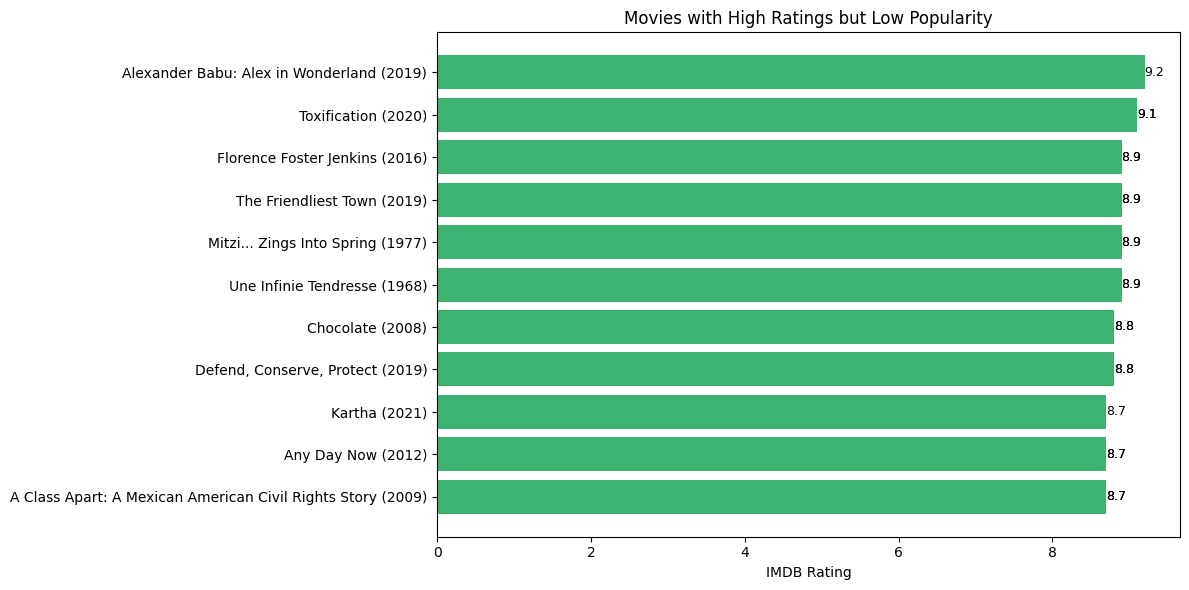

In [279]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Filter movies with high ratings and low popularity
# Adjust thresholds as needed (e.g., rating ≥ 8.0 and popularity ≤ 1.0)
filtered_df = grouped_df[
    (grouped_df['type'] == 'MOVIE') &
    (grouped_df['imdb_score'] >= 8.0) &
    (grouped_df['imdb_votes'] <= 100)
].dropna(subset=['title', 'imdb_score'])

# Step 2: Create label with title and year
filtered_df['label'] = filtered_df['title'] + ' (' + filtered_df['release_year'].astype(str) + ')'

# Step 3: Sort by rating
filtered_df = filtered_df.sort_values(by='imdb_score', ascending=False).head(20)

# Step 4: Plot bar chart
plt.figure(figsize=(12, 6))
bars = plt.barh(filtered_df['label'], filtered_df['imdb_score'], color='mediumseagreen')
plt.xlabel('IMDB Rating')
plt.title('Movies with High Ratings but IMDB Low Popularity')
plt.gca().invert_yaxis()


# Step 5: Add value labels inside bars
plt.gca().bar_label(bars, fmt='%.1f', label_type='edge', color='black', fontsize=9)

plt.tight_layout()
plt.show()


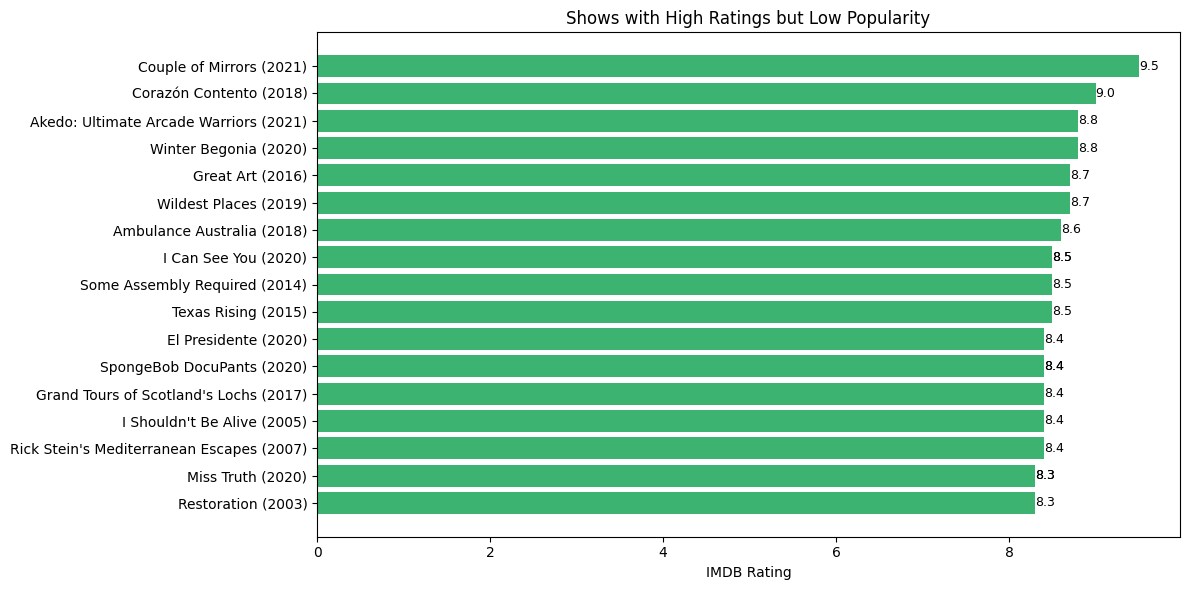

In [280]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Filter movies with high ratings and low popularity
# Adjust thresholds as needed (e.g., rating ≥ 8.0 and popularity ≤ 1.0)
filtered_df = grouped_df[
    (grouped_df['type'] == 'SHOW') &
    (grouped_df['imdb_score'] >= 8.0) &
    (grouped_df['imdb_votes'] <= 100)
].dropna(subset=['title', 'imdb_score'])

# Step 2: Create label with title and year
filtered_df['label'] = filtered_df['title'] + ' (' + filtered_df['release_year'].astype(str) + ')'

# Step 3: Sort by rating
filtered_df = filtered_df.sort_values(by='imdb_score', ascending=False).head(20)

# Step 4: Plot bar chart
plt.figure(figsize=(12, 6))
bars = plt.barh(filtered_df['label'], filtered_df['imdb_score'], color='mediumseagreen')
plt.xlabel('IMDB Rating')
plt.title('Shows with High Ratings but Low IMDB Popularity')
plt.gca().invert_yaxis()


# Step 5: Add value labels inside bars
plt.gca().bar_label(bars, fmt='%.1f', label_type='edge', color='black', fontsize=9)
plt.tight_layout()
plt.show()


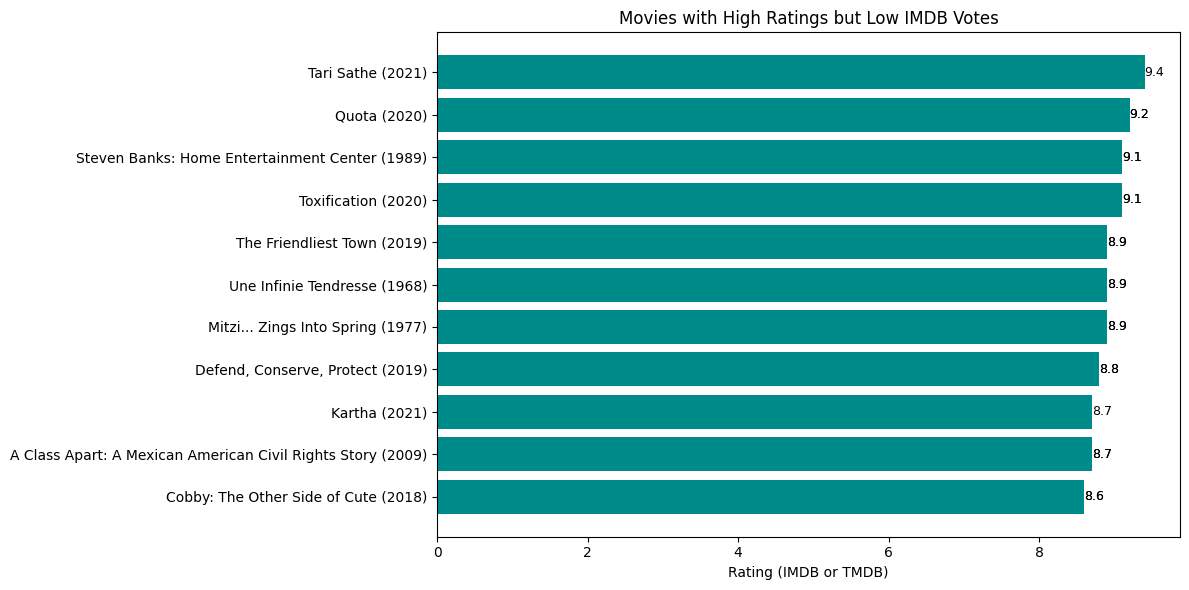

In [281]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Step 1: Create a fallback rating column
grouped_df['rating'] = grouped_df['imdb_score'].fillna(grouped_df['tmdb_score'])

# Step 2: Filter movies with low IMDB votes and high rating
filtered_df = grouped_df[
    (grouped_df['type'] == 'MOVIE') &
    (grouped_df['rating'] >= 8.0) &
    (grouped_df['tmdb_popularity'] <= 1.0)
].dropna(subset=['title', 'rating'])

# Step 3: Create label with title and year
filtered_df['label'] = filtered_df['title'] + ' (' + filtered_df['release_year'].astype(str) + ')'

# Step 4: Sort by rating
filtered_df = filtered_df.sort_values(by='rating', ascending=False).head(20)

# Step 5: Plot bar chart
plt.figure(figsize=(12, 6))
bars = plt.barh(filtered_df['label'], filtered_df['rating'], color='darkcyan')
plt.xlabel('Rating (TMDB)')
plt.title('Movies with High Ratings but Low TMDB Votes')
plt.gca().invert_yaxis()

# Step 6: Add value labels inside bars
plt.gca().bar_label(bars, fmt='%.1f', label_type='edge', color='black', fontsize=9)

plt.tight_layout()
plt.show()

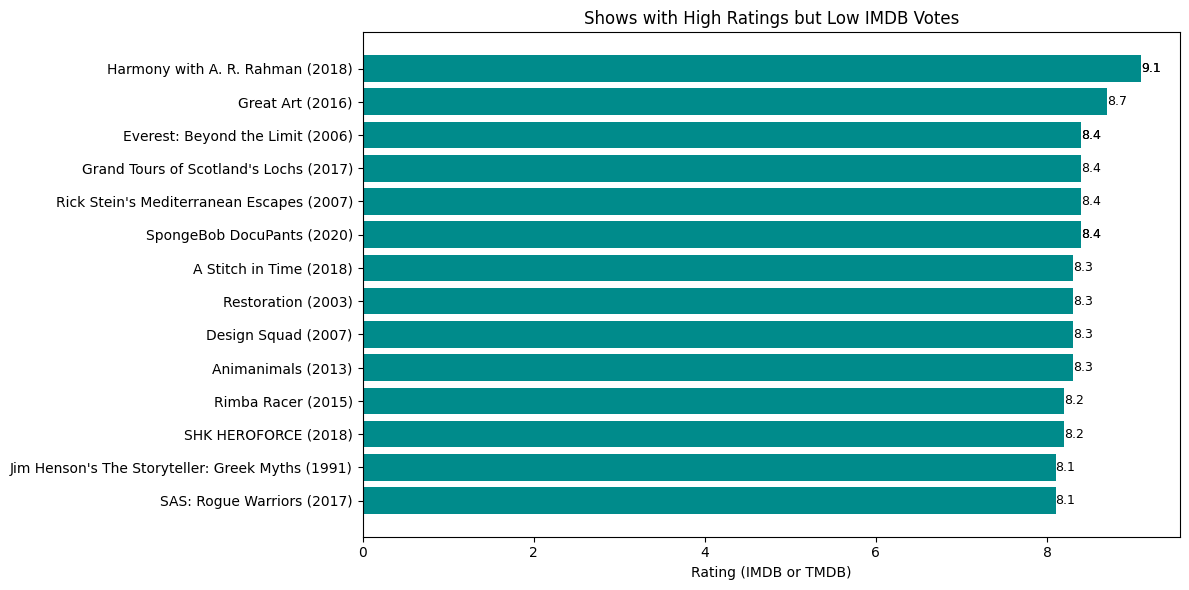

In [282]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Step 1: Create a fallback rating column
grouped_df['rating'] = grouped_df['imdb_score'].fillna(grouped_df['tmdb_score'])

# Step 2: Filter movies with low IMDB votes and high rating
filtered_df = grouped_df[
    (grouped_df['type'] == 'SHOW') &
    (grouped_df['rating'] >= 8.0) &
    (grouped_df['tmdb_popularity'] <= 1.0)
].dropna(subset=['title', 'rating'])

# Step 3: Create label with title and year
filtered_df['label'] = filtered_df['title'] + ' (' + filtered_df['release_year'].astype(str) + ')'

# Step 4: Sort by rating
filtered_df = filtered_df.sort_values(by='rating', ascending=False).head(20)

# Step 5: Plot bar chart
plt.figure(figsize=(12, 6))
bars = plt.barh(filtered_df['label'], filtered_df['rating'], color='darkcyan')
plt.xlabel('Rating (TMDB)')
plt.title('Shows with High Ratings but Low TMDB Votes')
plt.gca().invert_yaxis()


# Step 6: Add value labels inside bars
plt.gca().bar_label(bars, fmt='%.1f', label_type='edge', color='black', fontsize=9)

plt.tight_layout()
plt.show()